In [2]:
# Import Libraries

import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.impute import KNNImputer

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) #It adjust the configuration of the plots

In [3]:
# Reading the data

df = pd.read_csv('movies.csv')


In [4]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [5]:
df.duplicated().sum()

0

In [6]:
# Looking if any duplicates are there in the dataset.
print(df.duplicated(subset=['name', 'year', 'director']).sum())

0


In [7]:
# Looking at the columns with missing data

missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing Percent': df.isnull().mean() * 100
})
print(missing[missing['Missing Count'] > 0]) 

          Missing Count  Missing Percent
rating               77         1.004173
released              2         0.026082
score                 3         0.039124
votes                 3         0.039124
writer                3         0.039124
star                  1         0.013041
country               3         0.039124
budget             2171        28.312467
gross               189         2.464789
company              17         0.221701
runtime               4         0.052165


In [8]:
# Drop specific columns
# These columns contain specific real-world facts ('released', 'writer', 'star','country', 'company') that cannot be estimated,
# and missing count is less than 0.3% — dropping these rows results in negligible data loss.

df.dropna(subset=[
    'released', 'writer', 'star',
    'country', 'company'
], inplace=True)


In [9]:
# Group fill for category column
df['rating'] = df.groupby('genre')['rating']\
                 .transform(lambda x: x.fillna(
                     x.mode()[0] if not x.mode().empty else 'R'
                 ))

In [10]:
# KNN (K Nearest Neighbors) for ALL numeric columns together
# KNNImputer finds the most similar rows in your data and uses their values to fill the missing gap
num_cols = ['score', 'votes', 'budget', 'gross', 'runtime']
imputer  = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

In [11]:
print(df.isnull().sum())

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7646 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7646 non-null   object 
 1   rating    7646 non-null   object 
 2   genre     7646 non-null   object 
 3   year      7646 non-null   int64  
 4   released  7646 non-null   object 
 5   score     7646 non-null   float64
 6   votes     7646 non-null   float64
 7   director  7646 non-null   object 
 8   writer    7646 non-null   object 
 9   star      7646 non-null   object 
 10  country   7646 non-null   object 
 11  budget    7646 non-null   float64
 12  gross     7646 non-null   float64
 13  company   7646 non-null   object 
 14  runtime   7646 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 955.8+ KB


In [13]:
# Change the datatypes
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

In [14]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7660,Aloha Surf Hotel,R,Comedy,2020,"November 5, 2020 (United States)",7.1,14.0,Stefan C. Schaefer,Stefan C. Schaefer,Augie Tulba,United States,373750,301408,Abominable Pictures,90.0
7661,Love by Drowning,R,Drama,2020,"November 6, 2020 (United States)",7.3,24800.0,Justin Kreinbrink,C.E. Poverman,Nicky Whelan,United States,1000000,40872406,Dow Jazz Films,121.0
7664,Dream Round,R,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,373750,301408,Cactus Blue Entertainment,90.0
7665,Saving Mbango,R,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,301408,Embi Productions,95.2


In [15]:
# Extract year from released and convert to int to match year column
df['released_year'] = df['released'].str.extract(r'(\d{4})')[0].astype(int)

# Now compare both int columns
mismatched = df[df['year'] != df['released_year']]

print('Total mismatched rows:', len(mismatched))

mismatched.head(10)

Total mismatched rows: 1322


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
8,Superman II,PG,Action,1980,"June 19, 1981 (United States)",6.8,101000.0,Richard Lester,Jerry Siegel,Gene Hackman,United States,54000000,108185706,Dovemead Films,127.0,1981
11,The Gods Must Be Crazy,PG,Adventure,1980,"October 26, 1984 (United States)",7.3,54000.0,Jamie Uys,Jamie Uys,N!xau,South Africa,5000000,30031783,C.A.T. Films,109.0,1984
21,Heaven's Gate,R,Adventure,1980,"April 24, 1981 (United States)",6.8,14000.0,Michael Cimino,Michael Cimino,Kris Kristofferson,United States,44000000,3484523,Partisan Productions,219.0,1981
33,Cattle Annie and Little Britches,PG,Drama,1980,"April 24, 1981 (United States)",6.1,604.0,Lamont Johnson,David Eyre,Scott Glenn,United States,5100000,534816,Cattle Annie Productions,97.0,1981
40,The Watcher in the Woods,PG,Family,1980,"October 9, 1981 (United States)",6.3,5700.0,John Hough,Brian Clemens,Bette Davis,United States,1935000,5000000,Walt Disney Productions,84.0,1981
49,Lion of the Desert,PG,Biography,1980,"May 16, 1981 (Japan)",8.3,15000.0,Moustapha Akkad,David Butler,Anthony Quinn,Libya,35000000,19098920,Falcon International Productions,173.0,1981
54,City of Women,R,Comedy,1980,"April 8, 1981 (United States)",7.0,6700.0,Federico Fellini,Federico Fellini,Marcello Mastroianni,Italy,4935000,12516,Opera Film Produzione,139.0,1981
59,Hangar 18,PG,Sci-Fi,1980,"March 13, 1981 (Ireland)",5.3,2400.0,James L. Conway,Ken Pettus,Darren McGavin,United States,11000000,7283495,Sunn Classic Pictures,97.0,1981
62,It's My Turn,R,Comedy,1980,"February 5, 1981 (Argentina)",5.5,875.0,Claudia Weill,Eleanor Bergstein,Jill Clayburgh,United States,8020000,2852634,Rastar Films,91.0,1981
79,Windwalker,PG,Adventure,1980,"November 18, 1983 (Sweden)",6.9,1000.0,Kieth Merrill,Ray Goldrup,Trevor Howard,United States,3000000,2239814,Santa Fe International,108.0,1983


In [16]:
df.head(10)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980
5,Friday the 13th,R,Horror,1980,"May 9, 1980 (United States)",6.4,123000.0,Sean S. Cunningham,Victor Miller,Betsy Palmer,United States,550000,39754601,Paramount Pictures,95.0,1980
6,The Blues Brothers,R,Action,1980,"June 20, 1980 (United States)",7.9,188000.0,John Landis,Dan Aykroyd,John Belushi,United States,27000000,115229890,Universal Pictures,133.0,1980
7,Raging Bull,R,Biography,1980,"December 19, 1980 (United States)",8.2,330000.0,Martin Scorsese,Jake LaMotta,Robert De Niro,United States,18000000,23402427,Chartoff-Winkler Productions,129.0,1980
8,Superman II,PG,Action,1980,"June 19, 1981 (United States)",6.8,101000.0,Richard Lester,Jerry Siegel,Gene Hackman,United States,54000000,108185706,Dovemead Films,127.0,1981
9,The Long Riders,R,Biography,1980,"May 16, 1980 (United States)",7.0,10000.0,Walter Hill,Bill Bryden,David Carradine,United States,10000000,15795189,United Artists,100.0,1980


In [17]:
# Dropping year column as released_year has the correct data
df.drop(columns=['year'], inplace=True)

In [18]:
df.head()

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
0,The Shining,R,Drama,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980


In [19]:
# Sorting the data with highest gross
df.sort_values(by=['gross'], inplace=False, ascending=False)

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
5445,Avatar,PG-13,Action,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,"Love, Honor and Obey",R,Comedy,"February 9, 2001 (United States)",6.5,5200.0,Dominic Anciano,Dominic Anciano,Sadie Frost,United Kingdom,4295000,1400,British Broadcasting Corporation (BBC),103.0,2001
7625,The Untold Story,R,Comedy,"January 11, 2019 (United States)",5.7,320.0,Shane Stanley,Lee Stanley,Miko Hughes,United States,2300600,790,Visual Arts Entertainment,104.0,2019
7580,Run with the Hunted,Not Rated,Crime,"June 26, 2020 (United States)",5.2,735.0,John Swab,John Swab,Ron Perlman,United States,729600,682,Roxwell Films,93.0,2020
2417,Madadayo,R,Drama,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134.0,1993


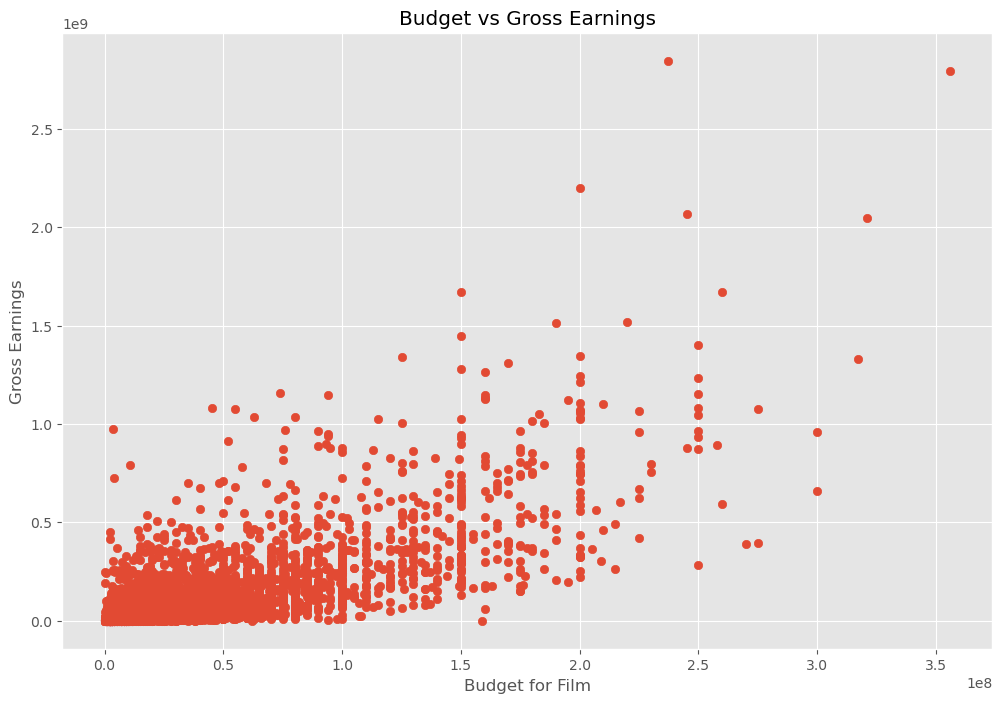

In [41]:
# Scatter Plot with budget vs Gross revenue

plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for Film')
plt.ylabel('Gross Earnings')
plt.show()

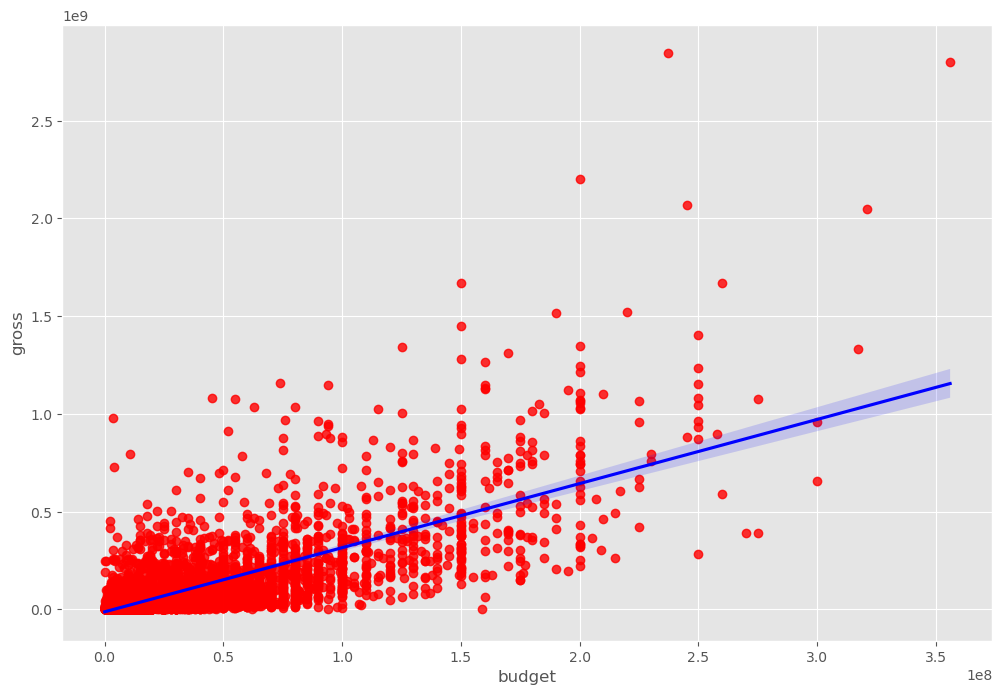

In [49]:
# Plot the budget vs gross using seaborn

sns.regplot(x='budget', y='gross',data = df, scatter_kws = {"color":"red"},line_kws = {"color":"blue"})
plt.show()

In [65]:
df.corr(numeric_only=True, method = 'pearson') #pearson, kendall, spearman - different methods in correlation 

,score,votes,budget,gross,runtime,released_year
score,1.000000,0.409393,0.063390,0.186301,0.399882,0.105941
votes,0.409393,1.000000,0.485334,0.632611,0.308840,0.218444
budget,0.063390,0.485334,1.000000,0.752842,0.276577,0.301217
gross,0.186301,0.632611,0.752842,1.000000,0.245086,0.254660
runtime,0.399882,0.308840,0.276577,0.245086,1.000000,0.119657
released_year,0.105941,0.218444,0.301217,0.254660,0.119657,1.000000


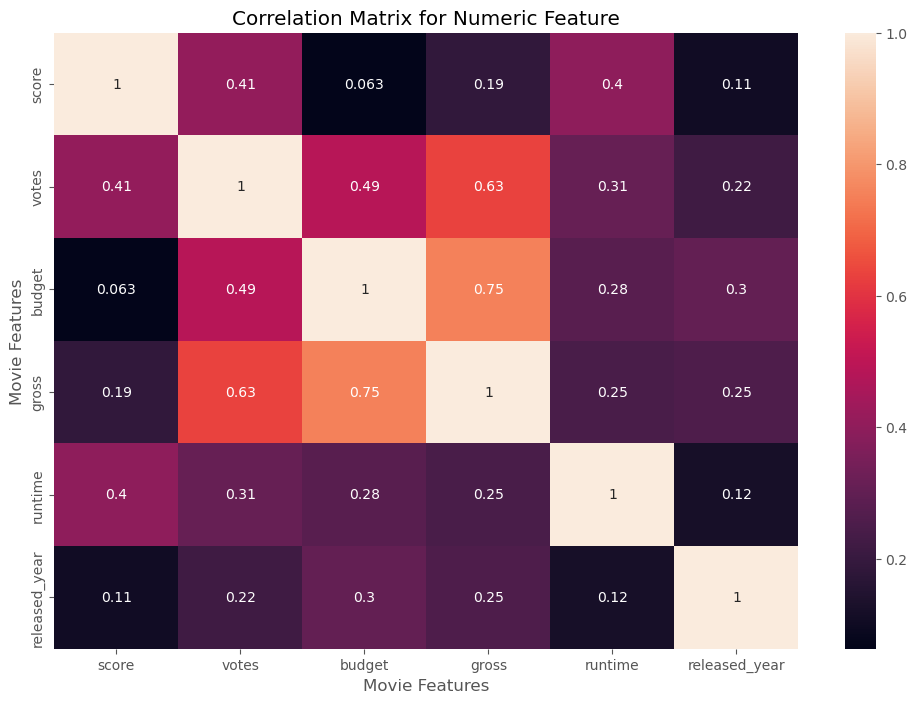

In [78]:
# Some columns are highly correlated one is budget and gross are highly correlated (0.75),
# meaning higher budget = higher earnings

correlation_matrix = df.corr(method = 'pearson', numeric_only = True)
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for Numeric Feature')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [85]:
# Category  is turned to numeric values.

df_numerized = df.copy()

for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized

,name,rating,genre,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_year
0,6569,6,6,1702,8.4,927000.0,2579,4002,1041,54,19000000,46998772,2314,146.0,1980
1,5558,6,1,1489,5.8,65000.0,2262,1629,325,55,4500000,58853106,727,104.0,1980
2,5129,4,0,1768,8.7,1200000.0,1109,2559,1737,55,18000000,538375067,1535,124.0,1980
3,285,4,4,1489,7.7,221000.0,1297,1995,2238,55,3500000,83453539,1807,88.0,1980
4,1026,6,4,1540,7.3,108000.0,1052,518,408,55,6000000,39846344,1772,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7660,337,6,4,2756,7.1,14.0,2581,3979,194,55,373750,301408,83,90.0,2020
7661,3347,6,6,2769,7.3,24800.0,1542,577,1988,55,1000000,40872406,880,121.0,2020
7664,1676,6,4,1104,4.7,36.0,773,2606,1878,55,373750,301408,535,90.0,2020
7665,4705,6,6,191,5.7,29.0,2054,2674,2032,55,58750,301408,937,95.2,2020


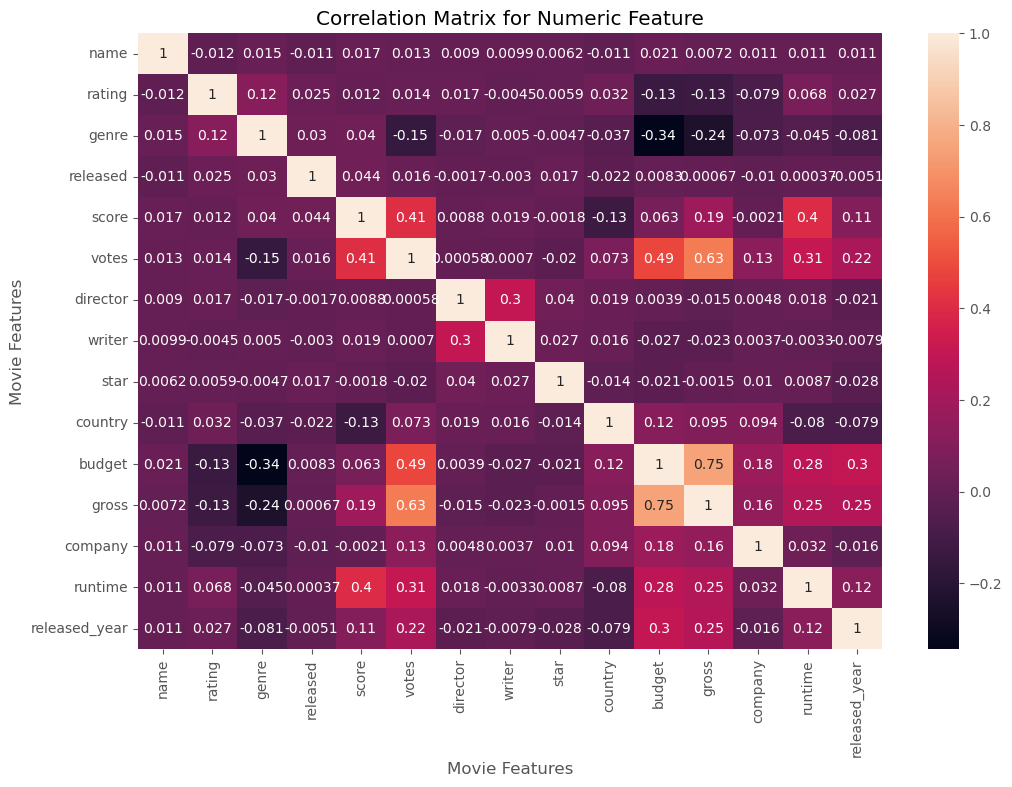

In [87]:
correlation_matrix = df_numerized.corr(method = 'pearson', numeric_only = True)
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for Numeric Feature')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [89]:
# Votes and budget have the highest correlation to gross earnings .
# Company was low correlation.